In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
ROOT         = Path("..").resolve()
RAW_DIR      = ROOT / "data" / "raw"
CONFIG_PATH  = ROOT / "configs" / "model_params.yml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

cat_map = {
    symbol: category
    for category, symbols in config["tickers"].items()
    for symbol in symbols
}

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Imports done.")

Imports done.


In [3]:
history  = pd.read_csv(RAW_DIR / "eps_history.csv",  parse_dates=["period_end_date"])
estimate = pd.read_csv(RAW_DIR / "eps_estimate.csv", parse_dates=["date", "period_end_date"])

In [4]:
history.shape
history.dtypes

act_symbol                    str
period_end_date    datetime64[us]
reported                  float64
estimate                  float64
category                      str
dtype: object

In [5]:
estimate.shape
estimate.dtypes

date               datetime64[us]
act_symbol                    str
period                        str
period_end_date    datetime64[us]
consensus                 float64
recent                    float64
count                     float64
high                      float64
low                       float64
year_ago                  float64
category                      str
dtype: object

In [6]:
history.head()

,act_symbol,period_end_date,reported,estimate,category
0,ABBV,2017-12-31,1.48,1.44,regulatory_idiosyncratic
1,ABBV,2018-03-31,1.87,1.80,regulatory_idiosyncratic
2,ABBV,2018-06-30,2.00,1.98,regulatory_idiosyncratic
3,ABBV,2018-09-30,2.14,2.01,regulatory_idiosyncratic
4,ABBV,2018-12-31,1.90,1.92,regulatory_idiosyncratic


In [7]:
estimate.head()

,date,act_symbol,period,period_end_date,consensus,recent,count,high,low,year_ago,category
0,2017-11-03,ABBV,Current Quarter,2017-12-31,1.43,1.46,8.0,1.46,1.42,1.20,regulatory_idiosyncratic
1,2017-11-03,ABBV,Current Year,2017-12-31,5.54,5.58,10.0,5.59,5.49,4.82,regulatory_idiosyncratic
2,2017-11-14,ABBV,Current Quarter,2017-12-31,1.43,1.46,8.0,1.46,1.42,1.20,regulatory_idiosyncratic
3,2017-11-14,ABBV,Current Year,2017-12-31,5.55,5.53,10.0,5.59,5.53,4.82,regulatory_idiosyncratic
4,2017-11-20,ABBV,Current Quarter,2017-12-31,1.43,1.46,8.0,1.46,1.42,1.20,regulatory_idiosyncratic


In [8]:
print("eps_history nulls")
print(history.isnull().sum())
print()
print("eps_estimate nulls")
print(estimate.isnull().sum())

eps_history nulls
act_symbol         0
period_end_date    0
reported           2
estimate           5
category           0
dtype: int64

eps_estimate nulls
date                  0
act_symbol            0
period                0
period_end_date       0
consensus           248
recent             3881
count               247
high                248
low                 248
year_ago            146
category              0
dtype: int64


In [9]:
print("Missing reported")
print(history[history["reported"].isnull()][["act_symbol", "period_end_date", "reported", "estimate"]])
print()
print("Missing estimate")
print(history[history["estimate"].isnull()][["act_symbol", "period_end_date", "reported", "estimate"]])

Missing reported
     act_symbol period_end_date  reported  estimate
1202        LIN      2018-09-30       NaN       NaN
1203        LIN      2018-12-31       NaN       NaN

Missing estimate
     act_symbol period_end_date  reported  estimate
326        ASML      2022-09-30      4.32       NaN
1202        LIN      2018-09-30       NaN       NaN
1203        LIN      2018-12-31       NaN       NaN
2190        TSM      2018-09-30      0.56       NaN
2194        TSM      2019-09-30      0.62       NaN


In [10]:
history["forecast_error"] = history["reported"] - history["estimate"]
print(history["forecast_error"].describe())

count    2455.000000
mean        0.168607
std         0.796219
min       -13.470000
25%         0.020000
50%         0.080000
75%         0.200000
max        23.860000
Name: forecast_error, dtype: float64


In [11]:
print("Largest positive surprises")
print(history.nlargest(10, "forecast_error")[["act_symbol", "period_end_date", "reported", "estimate", "forecast_error", "category"]])
print()
print("Largest negative surprises")
print(history.nsmallest(10, "forecast_error")[["act_symbol", "period_end_date", "reported", "estimate", "forecast_error", "category"]])

Largest positive surprises
    act_symbol period_end_date  reported  estimate  forecast_error  \
255       AMZN      2021-12-31     27.75      3.89           23.86   
905         GS      2021-03-31     18.60      9.79            8.81   
249       AMZN      2020-06-30     10.30      1.74            8.56   
251       AMZN      2020-12-31     14.09      7.05            7.04   
252       AMZN      2021-03-31     15.79      9.75            6.04   
907         GS      2021-09-30     14.93      9.78            5.15   
906         GS      2021-06-30     15.02      9.90            5.12   
904         GS      2020-12-31     12.08      6.99            5.09   
250       AMZN      2020-09-30     12.37      7.30            5.07   
903         GS      2020-09-30      9.68      5.58            4.10   

                  category  
255  economically_cyclical  
905   macro_rate_sensitive  
249  economically_cyclical  
251  economically_cyclical  
252  economically_cyclical  
907   macro_rate_sensitive  

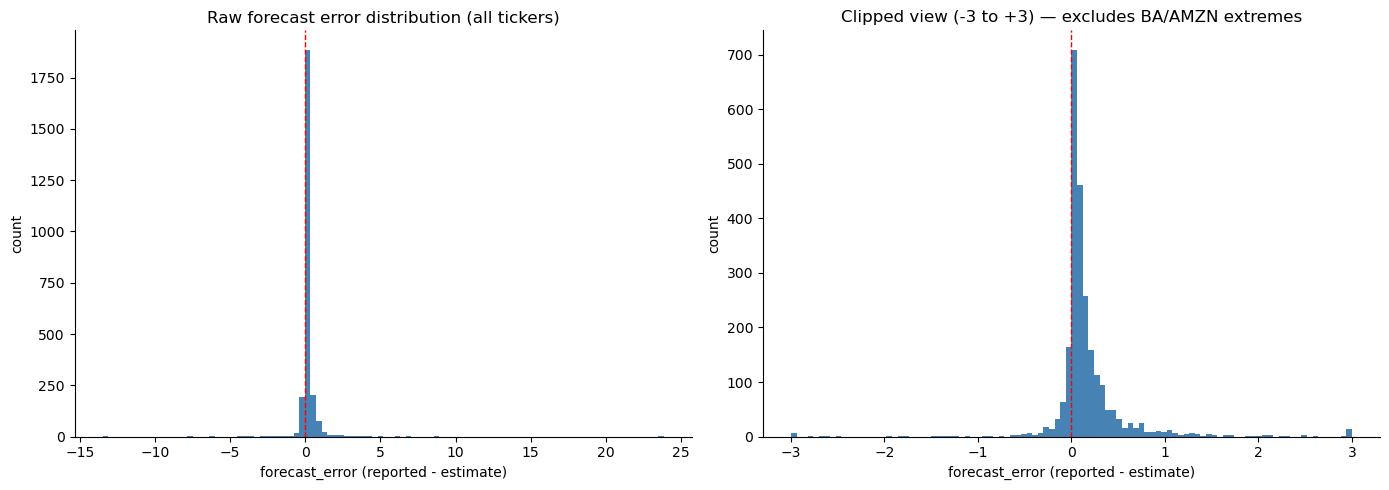

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(history["forecast_error"].dropna(), bins=100, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Raw forecast error distribution (all tickers)")
axes[0].set_xlabel("forecast_error (reported - estimate)")
axes[0].set_ylabel("count")

clipped = history["forecast_error"].clip(-3, 3)
axes[1].hist(clipped.dropna(), bins=100, color="steelblue", edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Clipped view (-3 to +3) — excludes BA/AMZN extremes")
axes[1].set_xlabel("forecast_error (reported - estimate)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("../reports/figures/01_forecast_error_distribution.png", dpi=150)
plt.show()

In [13]:
category_bias = (
    history.groupby("category")["forecast_error"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
)
print(category_bias)

                           mean  median    std  count
category                                             
macro_rate_sensitive      0.256   0.075  0.784    408
economically_cyclical     0.192   0.100  1.693    415
commodity_driven          0.180   0.100  0.330    406
tech_cycle                0.175   0.100  0.295    408
regulatory_idiosyncratic  0.156   0.110  0.258    408
defensive_baseline        0.053   0.030  0.089    410


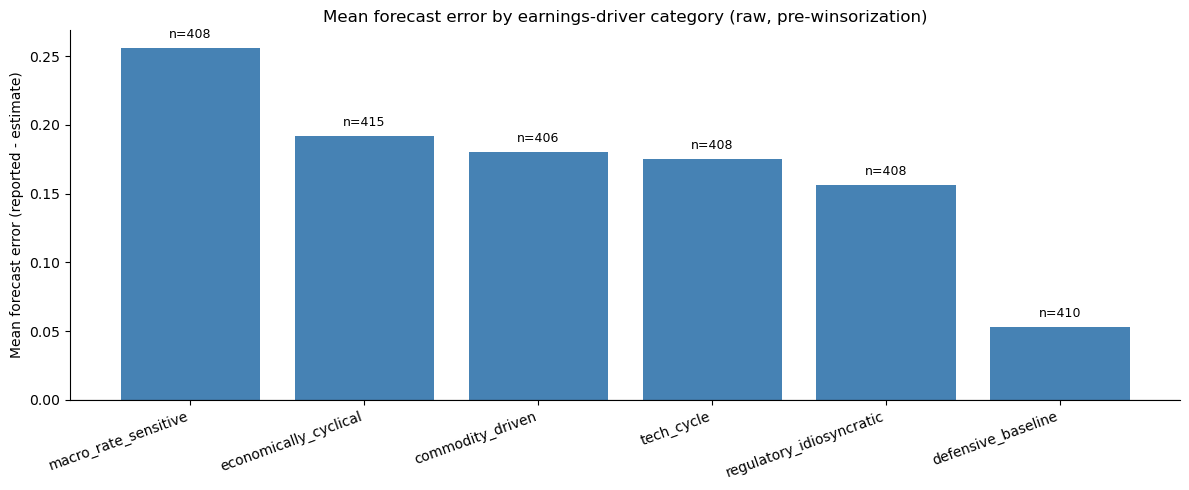

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

categories = category_bias.index.tolist()
means      = category_bias["mean"].values
stds       = category_bias["std"].values
counts     = category_bias["count"].values

bars = ax.bar(categories, means, color="steelblue", edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean forecast error by earnings-driver category (raw, pre-winsorization)")
ax.set_ylabel("Mean forecast error (reported - estimate)")
ax.set_xlabel("")
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=20, ha="right")

# Annotate with count
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={count}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.savefig("../reports/figures/01_category_bias.png", dpi=150)
plt.show()

In [15]:
print(history[history["act_symbol"] == "DE"][["act_symbol", "period_end_date", "reported", "estimate"]].to_string())

    act_symbol period_end_date  reported  estimate
717         DE      2017-10-31      1.57      1.46
718         DE      2018-01-31      1.31      1.16
719         DE      2018-04-30      3.14      3.33
720         DE      2018-07-31      2.59      2.77
721         DE      2018-10-31      2.30      2.44
722         DE      2019-01-31      1.54      1.80
723         DE      2019-04-30      3.52      3.58
724         DE      2019-07-31      2.71      2.80
725         DE      2019-10-31      2.14      2.13
726         DE      2020-01-31      1.63      1.28
727         DE      2020-04-30      2.11      1.77
728         DE      2020-07-31      2.57      1.30
729         DE      2020-10-31      2.39      1.44
730         DE      2020-12-31      0.89      0.76
731         DE      2021-01-31      3.87      2.15
732         DE      2021-03-31      0.58      0.62
733         DE      2021-04-30      5.68      4.44
734         DE      2021-06-30      0.74      0.65
735         DE      2021-07-31 

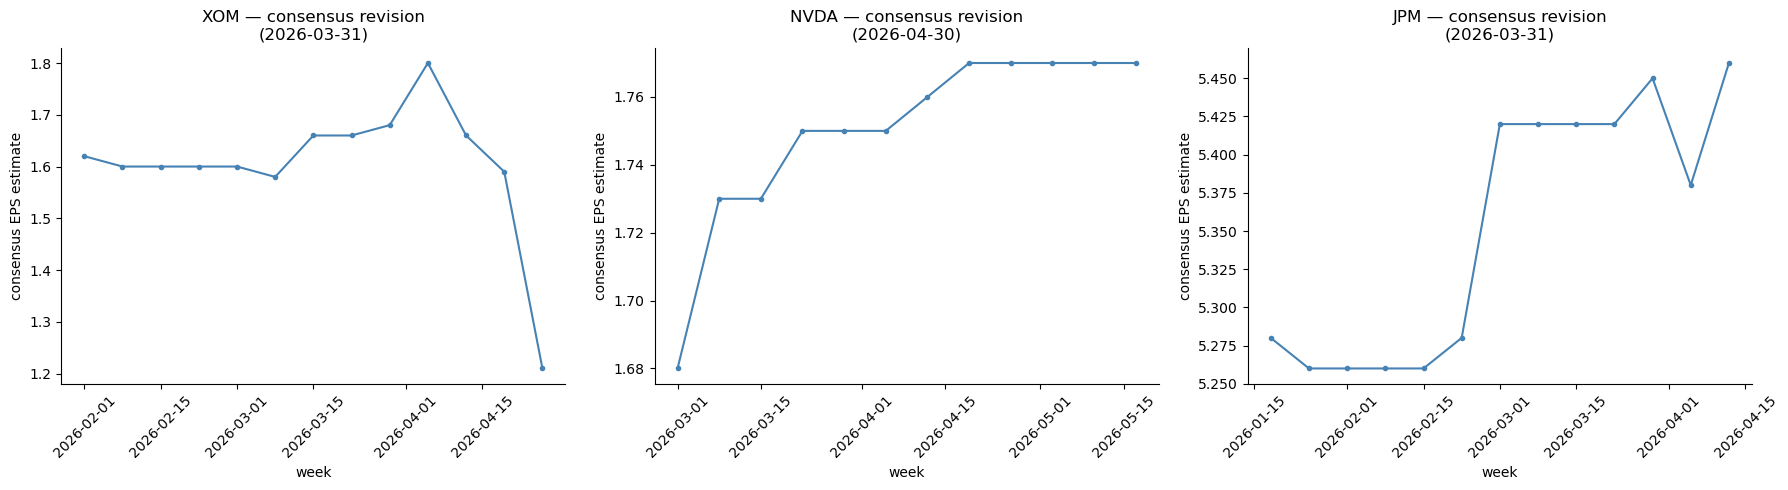

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tickers_to_check = ["XOM", "NVDA", "JPM"]

for ax, ticker in zip(axes, tickers_to_check):
    df = estimate[
        (estimate["act_symbol"] == ticker) &
        (estimate["period"] == "Current Quarter")
    ].copy()
    
    latest_period = df[df["period_end_date"] < pd.Timestamp("today")]["period_end_date"].max()
    df_q = df[df["period_end_date"] == latest_period].sort_values("date")
    
    ax.plot(df_q["date"], df_q["consensus"], marker="o", markersize=3, color="steelblue")
    ax.set_title(f"{ticker} — consensus revision\n({latest_period.date()})")
    ax.set_xlabel("week")
    ax.set_ylabel("consensus EPS estimate")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/01_revision_path_sanity.png", dpi=150)
plt.show()